# Imports, Primitives

In [ ]:
from google.colab import drive
import os
import time
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import requests
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, regularizers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from PIL import Image, ImageFont
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import math

drive.mount('/content/drive')

ZIP_SRC  = "/content/drive/MyDrive/Deep Learning Project/GoogleStreetViewImagesNew.zip"
LOCAL_DIR = "/content/streetview_dataset"

if not os.path.exists(LOCAL_DIR):
    t0 = time.time()
    !cp "{ZIP_SRC}" /content/streetview_dataset.zip
    !unzip -q /content/streetview_dataset.zip -d {LOCAL_DIR}
    print(f"Staged in {time.time() - t0:.1f}s")

!ls {LOCAL_DIR} | head

Mounted at /content/drive
Staged in 61.5s
GoogleStreetViewImagesNew
__MACOSX


In this notebook, we show how fine-tuning different pre-trained models on image classification can be used for identifying income thirds from Google Street Imgery data from Boston. To benchmark and compare model performance across different pre-trained architectures, we monitor the following metrics:

# Single-Heading Pre-trained CNN

## Data Loading Function

In [ ]:
def dataloading(csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-2.csv",
                img_size=224,
                batch_size=32,
                preprocess_fn=None,
                ordinal=None):

    # 1. Load CSV
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["income_group"]).reset_index(drop=True)

    # 2. Build file paths and group IDs
    df["full_path"] = df["file_path"].apply(
        lambda f: os.path.join("/content/streetview_dataset/", f)
    )
    df["loc_id"] = df["file_path"].apply(
        lambda f: os.path.basename(f).split("_h")[0]
    )

    # 3. Filter missing files before splitting
    before = len(df)
    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"Dropped {before - len(df)} missing files, {len(df)} remaining")

    # 4. Train / Val / Test split at location level
    locs = df["loc_id"].unique()
    np.random.seed(50)
    np.random.shuffle(locs)
    n_test = int(len(locs) * 0.15)
    n_val  = int(len(locs) * 0.15)
    test_locs  = locs[:n_test]
    val_locs   = locs[n_test:n_test + n_val]
    train_locs = locs[n_test + n_val:]

    train_df = df[df["loc_id"].isin(train_locs)]
    val_df   = df[df["loc_id"].isin(val_locs)]
    test_df  = df[df["loc_id"].isin(test_locs)]

    def to_ordinal(y, num_classes=3):
        out = np.zeros((len(y), num_classes - 1), dtype=np.float32)
        for i, label in enumerate(y):
            out[i, :label] = 1.0
        return out

    train_labels = train_df["income_group"].values.astype(np.int64)
    val_labels   = val_df["income_group"].values.astype(np.int64)
    test_labels  = test_df["income_group"].values.astype(np.int64)

    if ordinal:
        train_labels = to_ordinal(train_labels, num_classes=3)
        val_labels   = to_ordinal(val_labels,   num_classes=3)
        test_labels  = to_ordinal(test_labels,  num_classes=3)

    splits = {
        "train": (train_df["full_path"].values, train_labels),
        "val":   (val_df["full_path"].values,   val_labels),
        "test":  (test_df["full_path"].values,  test_labels),
    }

    for k, (p, l) in splits.items():
        print(f"{k}: {len(p)} images")

    # 5. Image loading function
    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        img = tf.cast(img, tf.float32)
        if preprocess_fn:
            img = preprocess_fn(img)
        else:
            img = img / 255.0
        return img, label

    # 6. Build tf.data pipelines
    def make_dataset(file_paths, lbls, is_train=False):
        ds = tf.data.Dataset.from_tensor_slices((file_paths, lbls))
        ds = ds.cache()
        if is_train:
            ds = ds.shuffle(len(file_paths))
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    train_ds = make_dataset(*splits["train"], is_train=True)
    val_ds   = make_dataset(*splits["val"])
    test_ds  = make_dataset(*splits["test"])

    return train_ds, val_ds, test_ds


# ResNet50 Backbone Single-Heading Prediction

A pre-trained ResNet50 backbone serves as a frozen feature extractor, with a lightweight custom classification head trained on top.


## Architecture

```
Input Image (H × W × C)
        ↓
  Data Augmentation        ← random transforms at training time only
        ↓
  ResNet50 Backbone        ← frozen, pre-trained on ImageNet (~25M params)
        ↓
GlobalAveragePooling2D     ← collapses (H', W', 2048) → (2048,)
        ↓
  Dense(3, softmax)        ← outputs class probabilities
```

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

train_ds,val_ds , test_ds = dataloading(
    csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-3.csv",
    img_size=224,
    batch_size=32,
    preprocess_fn=tf.keras.applications.resnet50.preprocess_input
)

IMG_SHAPE = (224, 224, 3)


image_batch, label_batch = next(iter(train_ds))
print("Image batch shape :", image_batch.shape)
print("Label batch shape :", label_batch.shape)
print("Pixel value range :", image_batch.numpy().min(), "→", image_batch.numpy().max())

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# ── 4. Frozen ResNet50 backbone ────────────────────────────────────────────────
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# ── 5. Build model ─────────────────────────────────────────────────────────────
inputs = tf.keras.Input(shape=IMG_SHAPE, name="input_images")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)

x = tf.keras.layers.Dropout(0.4, name="dropout_1")(x)
x = tf.keras.layers.Dense(
        512, activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name="dense_hidden"
    )(x)
x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)
outputs = tf.keras.layers.Dense(
            3, activation="softmax",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="predictions"
          )(x)

model = tf.keras.Model(inputs, outputs, name="ResNet50_Improved")
model.summary()


def make_callbacks(ckpt="best_resnet50_improved.keras"):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        # ReduceLROnPlateau kept only for Phase 1 where LR is flat
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4,
            min_lr=1e-6, verbose=1
        ),
    ]

# ── 7. Phase 1 — Feature extraction (backbone frozen)
print("\n=== Phase 1: Feature Extraction (frozen backbone) ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=make_callbacks(),
    verbose=1
)

print("Test Evaluation (Phase 1)")
loss_p1, acc_p1 = model.evaluate(test_ds, verbose=1)
print(f"Test accuracy : {acc_p1:.4f}  |  Test loss : {loss_p1:.4f}")

# ── 8. Phase 2 — Fine-tuning (more layers unfrozen than before)
print("Phase 2: Fine-Tuning (top layers unfrozen)")

base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")

# Cosine decay instead of flat LR + ReduceLROnPlateau:
total_steps = 30 * len(train_ds)
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7,   # floor LR at the end of decay
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# No ReduceLROnPlateau in Phase 2 — cosine schedule handles LR on its own
callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/Deep Learning Project/best_resnet50_improved.keras",
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_p2,
    verbose=1
)

print("Test Evaluation (Phase 2 — Fine-tuned)")
loss_p2, acc_p2 = model.evaluate(test_ds, verbose=1)
print(f"Test accuracy : {acc_p2:.4f}  |  Test loss : {loss_p2:.4f}")

Dropped 0 missing files, 21906 remaining
train: 15338 images
val: 3284 images
test: 3284 images
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Pixel value range : -123.68 → 151.061
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 1,050,627 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


=== Phase 1: Feature Extraction (frozen backbone) ===
Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3890 - loss: 1.3390
Epoch 1: val_accuracy improved from None to 0.42844, saving model to best_resnet50_improved.keras

Epoch 1: finished saving model to best_resnet50_improved.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.4098 - loss: 1.2118 - val_accuracy: 0.4284 - val_loss: 1.1379 - learning_rate: 0.0010
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4513 - loss: 1.1248
Epoch 2: val_accuracy improved from 0.42844 to 0.43240, saving model to best_resnet50_improved.keras

Epoch 2: finished saving model to best_resnet50_improved.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.4437 - loss: 1.1202 - val_accuracy: 0.4324 - val_loss: 1.1254 - learning_rate: 0.0010
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4499 - loss: 1.1031
Epoch 3: val_accuracy improved from 0.43240 to 0.45828, saving model to

# EfficientNetV2S Backbone Single-Heading Prediction

A pre-trained EfficientNetV2S backbone serves as a frozen feature extractor, with a lightweight custom classification head trained on top.

## Architecture

    Input Image (H × W × C)
            ↓
      Data Augmentation        ← random transforms at training time only
            ↓
    EfficientNetV2S Backbone   ← frozen, pre-trained on ImageNet (~21M params)
            ↓
    GlobalAveragePooling2D     ← collapses (H', W', 1280) → (1280,)
            ↓
      Dense(3, softmax)        ← outputs class probabilities


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

# Load data
train_ds, val_ds, test_ds = dataloading(
    csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-3.csv",
    img_size=384,
    batch_size=16,
    preprocess_fn=tf.keras.applications.efficientnet_v2.preprocess_input
)

IMG_SHAPE = (384, 384, 3)

# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# EfficientNetV2S backbone
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Build model
inputs = tf.keras.Input(shape=IMG_SHAPE, name="input_images")
x = data_augmentation(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x = tf.keras.layers.Dropout(0.4, name="dropout_1")(x)
x = tf.keras.layers.Dense(
        512, activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name="dense_hidden"
    )(x)
x = tf.keras.layers.Dropout(0.4, name="dropout_2")(x)
outputs = tf.keras.layers.Dense(
            3, activation="softmax",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="predictions"
          )(x)

model = tf.keras.Model(inputs, outputs, name="EfficientNetV2S_Improved")
model.summary()

# Callbacks
def make_callbacks(ckpt="best_efficientnetv2s.keras"):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4,
            min_lr=1e-6, verbose=1
        ),
    ]

# Phase 1 — Feature extraction (backbone frozen)
print("\n=== Phase 1: Feature Extraction (frozen backbone) ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=make_callbacks(),
    verbose=1
)

print("\n=== Test Evaluation (Phase 1) ===")
loss_p1, acc_p1 = model.evaluate(test_ds, verbose=1)
print(f"Test accuracy : {acc_p1:.4f}  |  Test loss : {loss_p1:.4f}")

# Phase 2 — Fine-tuning
print("Phase 2: Fine-Tuning (top layers unfrozen)")

base_model.trainable = True

fine_tune_at = 340
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")

total_steps = 30 * len(train_ds)
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/Deep Learning Project/best_efficientnetv2s.keras",
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_p2,
    verbose=1
)

print("Test Evaluation (Phase 2 — Fine-tuned)")
loss_p2, acc_p2 = model.evaluate(test_ds, verbose=1)
print(f"Test accuracy : {acc_p2:.4f}  |  Test loss : {loss_p2:.4f}")

Dropped 0 missing files, 21906 remaining
train: 15338 images
val: 3284 images
test: 3284 images
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNetV2S_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)       │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,988,771 (80.07 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 20,331,360 (77.56 MB)


=== Phase 1: Feature Extraction (frozen backbone) ===
Epoch 1/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4284 - loss: 1.1700
Epoch 1: val_accuracy improved from None to 0.46924, saving model to best_efficientnetv2s.keras

Epoch 1: finished saving model to best_efficientnetv2s.keras
959/959 ━━━━━━━━━━━━━━━━━━━━ 89s 66ms/step - accuracy: 0.4542 - loss: 1.1264 - val_accuracy: 0.4692 - val_loss: 1.0812 - learning_rate: 0.0010
Epoch 2/20
958/959 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4856 - loss: 1.0850
Epoch 2: val_accuracy improved from 0.46924 to 0.50365, saving model to best_efficientnetv2s.keras

Epoch 2: finished saving model to best_efficientnetv2s.keras
959/959 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.4902 - loss: 1.0795 - val_accuracy: 0.5037 - val_loss: 1.0586 - learning_rate: 0.0010
Epoch 3/20
959/959 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5023 - loss: 1.0631
Epoch 3: val_accuracy improved from 0.50365 to 0.52801, saving model to best_ef

# Post-Hoc Aggregation of Single-Heading Prediction

Utilities for evaluating a trained image classifier on street-view test data at both the **image level** and the **location level**. `predict_per_image` builds a `tf.data` pipeline to run batched inference and collect per-image softmax probabilities. `aggregate_predictions` then folds those per-heading predictions up to a single location-level decision using five strategies,mean probability, majority vote, max confidence, median probability, and geometric mean. Finally, `evaluate_aggregations` benchmarks all five methods head-to-head, reporting accuracy, macro F1, and weighted F1 alongside a side-by-side confusion matrix plot saved to disk.

In [ ]:
def predict_per_image(model, test_df, img_size=224, batch_size=32, preprocess_fn=None):

    def load_image_infer(path):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        img = tf.cast(img, tf.float32)
        return preprocess_fn(img) if preprocess_fn else img / 255.0

    paths  = test_df["full_path"].values
    labels = test_df["income_group"].values.astype(np.int64)
    loc_ids = test_df["loc_id"].values

    ds = (
        tf.data.Dataset.from_tensor_slices(paths)
        .map(load_image_infer, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    all_probs = model.predict(ds, verbose=1)

    num_classes = all_probs.shape[1]
    pred_df = pd.DataFrame({
        "loc_id":    loc_ids,
        "true_label": labels,
        "pred_class": np.argmax(all_probs, axis=1),
        **{f"prob_class_{c}": all_probs[:, c] for c in range(num_classes)},
    })
    return pred_df

def aggregate_predictions(pred_df, num_classes=3):
    prob_cols = [f"prob_class_{c}" for c in range(num_classes)]
    results = {}

    for loc_id, grp in pred_df.groupby("loc_id"):
        # ── true label is the same for all headings of a location ──
        true_label = grp["true_label"].iloc[0]

        probs = grp[prob_cols].values  # shape (num_headings, num_classes)

        # Method 1 – Mean probability
        mean_pred  = np.argmax(probs.mean(axis=0))

        # Method 2 – Majority vote on per-image argmax
        per_image_preds = np.argmax(probs, axis=1)
        majority_pred   = stats.mode(per_image_preds, keepdims=True).mode[0]

        # Method 3 – Max confidence (pick the image with highest winning prob)
        max_probs   = probs.max(axis=1)
        best_image  = np.argmax(max_probs)
        maxconf_pred = per_image_preds[best_image]

        # Method 4 – Median probability
        median_pred = np.argmax(np.median(probs, axis=0))

        # Method 5 – Geometric mean of probabilities
        log_probs   = np.log(probs + 1e-9)
        geo_pred    = np.argmax(log_probs.mean(axis=0))

        for method, pred in [
            ("mean_prob",    mean_pred),
            ("majority_vote", majority_pred),
            ("max_confidence", maxconf_pred),
            ("median_prob",  median_pred),
            ("geometric_mean", geo_pred),
        ]:
            results.setdefault(method, []).append({
                "loc_id":     loc_id,
                "true_label": true_label,
                "agg_pred":   pred,
            })

    return {k: pd.DataFrame(v) for k, v in results.items()}


def evaluate_aggregations(agg_results, num_classes=3, class_names=None):

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    summary_rows = []
    fig, axes = plt.subplots(
        1, len(agg_results),
        figsize=(5 * len(agg_results), 4),
        constrained_layout=True,
    )
    if len(agg_results) == 1:
        axes = [axes]

    for ax, (method, df) in zip(axes, agg_results.items()):
        y_true = df["true_label"].values
        y_pred = df["agg_pred"].values

        acc  = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average="macro",  zero_division=0)
        f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        cm   = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

        summary_rows.append({
            "Method":      method,
            "Accuracy":    round(acc, 4),
            "F1 Macro":    round(f1_macro, 4),
            "F1 Weighted": round(f1_weighted, 4),
            "N Locations": len(df),
        })

        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar=False,
        )
        ax.set_title(method.replace("_", " ").title(), fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.suptitle("Confusion Matrices – Heading Aggregation Methods", fontsize=13, y=1.02)
    plt.savefig("aggregation_confusion_matrices.png", bbox_inches="tight", dpi=150)
    plt.show()

    summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
    print("\n" + "=" * 65)
    print("  AGGREGATION METHOD COMPARISON  (test set, loc_id level)")
    print("=" * 65)
    print(summary_df.to_string(index=False))
    print("=" * 65)
    return summary_df

Dropped 0 missing files, 21906 remaining
train: 15338 images
val: 3284 images
test: 3284 images
Model input shape: (None, 384, 384, 3)
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.6632 - loss: 0.8230

Image-level  →  Loss: 0.8230  |  Accuracy: 0.6632
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step

Per-image prediction DataFrame shape: (3284, 6)
            loc_id  true_label  pred_class  prob_class_0  prob_class_1  \
0  250250704021_p4           0           0      0.479259      0.196535   
1  250250812001_p0           0           2      0.042844      0.186001   
2  250251102011_p2           0           0      0.580472      0.258805   
3  2.5025E+11_p204           2           0      0.828624      0.053199   
4  250251102011_p3           0           1      0.075899      0.529641   

   prob_class_2  
0      0.324206  
1      0.771154  
2      0.160722  
3      0.118177  
4      0.394460  


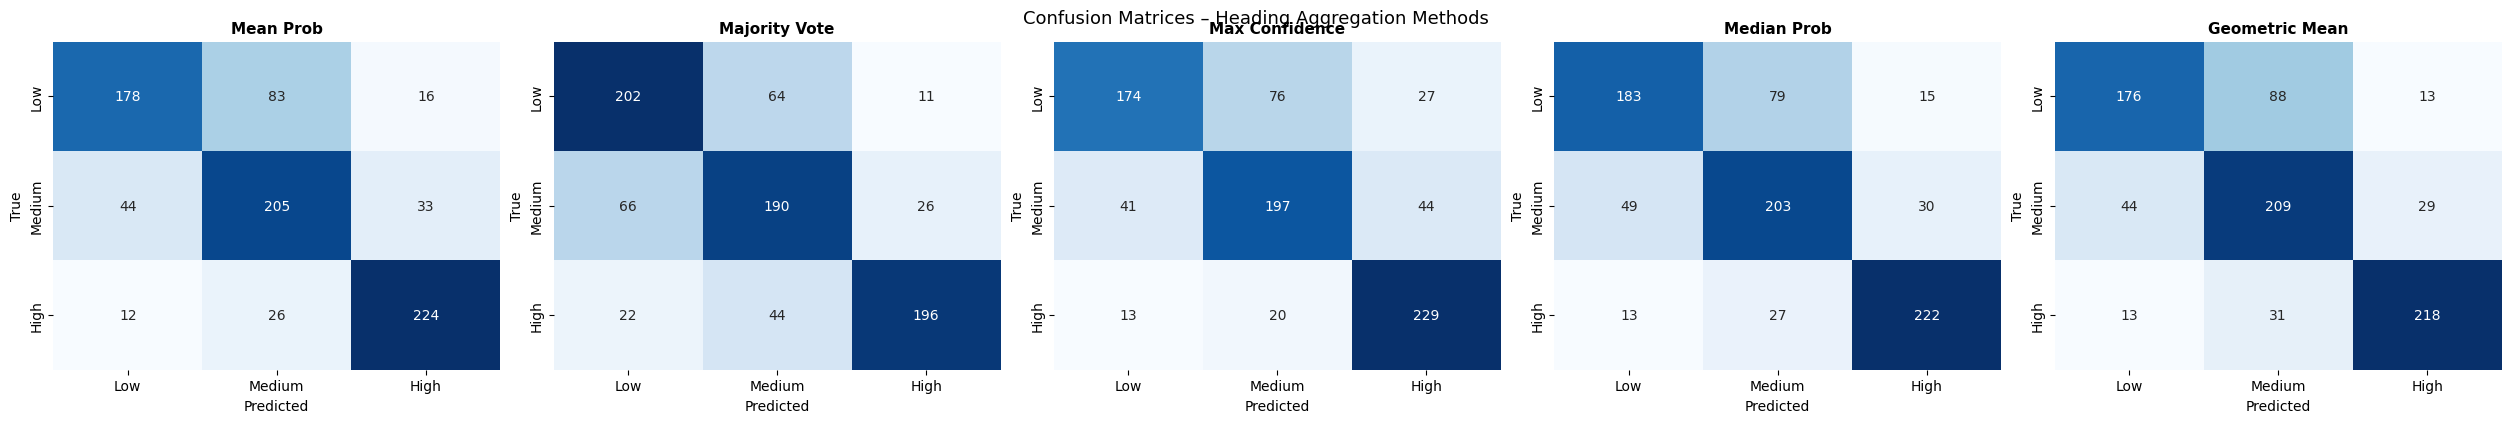


  AGGREGATION METHOD COMPARISON  (test set, loc_id level)
        Method  Accuracy  F1 Macro  F1 Weighted  N Locations
   median_prob    0.7406    0.7425       0.7404          821
     mean_prob    0.7393    0.7407       0.7386          821
geometric_mean    0.7345    0.7369       0.7348          821
max_confidence    0.7308    0.7298       0.7279          821
 majority_vote    0.7162    0.7199       0.7182          821

Detailed results for best method 'median_prob':
              loc_id  true_label  agg_pred
0  2.50251E+11_p1013           2         2
1  2.50251E+11_p1017           2         1
2  2.50251E+11_p1025           2         2
3  2.50251E+11_p1033           2         0
4   2.50251E+11_p107           0         0
5  2.50251E+11_p1081           2         2
6  2.50251E+11_p1087           2         2
7  2.50251E+11_p1104           2         2
8  2.50251E+11_p1113           2         2
9  2.50251E+11_p1114           2         2


In [ ]:
if __name__ == "__main__":
    IMG_SIZE   = 384
    BATCH_SIZE = 16
    PREPROCESS = tf.keras.applications.efficientnet_v2.preprocess_input

    train_ds, val_ds, test_ds, test_df = dataloading(
        csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-3.csv",
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        preprocess_fn=PREPROCESS,
    )


    model = tf.keras.models.load_model(
        "/content/drive/MyDrive/Deep Learning Project/best_efficientnetv2s.keras"
    )
    print("Model input shape:", model.input_shape)

    loss, acc = model.evaluate(test_ds, verbose=1)
    print(f"\nImage-level  →  Loss: {loss:.4f}  |  Accuracy: {acc:.4f}")

    pred_df = predict_per_image(
        model, test_df,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        preprocess_fn=PREPROCESS,
    )
    print(f"\nPer-image prediction DataFrame shape: {pred_df.shape}")
    print(pred_df.head())

    num_classes = model.output_shape[-1]
    agg_results = aggregate_predictions(pred_df, num_classes=num_classes)

    class_names = ["Low", "Medium", "High"]
    summary_df  = evaluate_aggregations(agg_results, num_classes=num_classes,
                                         class_names=class_names)

    best_method = summary_df.iloc[0]["Method"]
    print(f"\nDetailed results for best method '{best_method}':")
    print(agg_results[best_method].head(10))

# Multi-Heading Prediction

A pre-trained EfficientNetV2S backbone is shared across the four cardinal headings (0°, 90°, 180°, 270°) of each location via a TimeDistributed wrapper, then the four per-view embeddings are fused into a single location-level prediction. Four fusion variants are trained and benchmarked, named `backbone_<fusion>` to match the training charts:

- `EfficientNetV2S_avg` — average pooling across the 4 views
- `EfficientNetV2S_max` — max pooling across the 4 views
- `EfficientNetV2S_avg_max` — concatenation of average and max pooling
- `EfficientNetV2S_avg_max_pos` — concatenation of average and max pooling, with a learned sinusoidal positional encoding of the heading angle added before fusion

## Architecture

    Input (4 × H × W × C)              ← 4 cardinal views per location
            ↓
    TimeDistributed(Augmentation)      ← per-view random transforms (train only)
            ↓
    TimeDistributed(EfficientNetV2S)   ← shared frozen backbone (~21M params)
            ↓
    TimeDistributed(GlobalAvgPool2D)   ← (batch, 4, 1280)

In [ ]:
IMG_SIZE   = 384
BATCH_SIZE = 16
EPOCHS_P1  = 20
EPOCHS_P2  = 30
CSV_PATH   = "/content/drive/MyDrive/Deep Learning Project/images_bra-3.csv"
PREPROCESS = tf.keras.applications.efficientnet_v2.preprocess_input

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# SHARED DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

def fresh_backbone():
    bm = tf.keras.applications.EfficientNetV2S(
        input_shape=IMG_SHAPE, include_top=False, weights="imagenet"
    )
    bm.trainable = False
    return bm

# Positional encoding constant
HEADINGS = [0, 90, 180, 270]
_angles  = np.array(HEADINGS) * np.pi / 180.0
_pos_enc = np.stack(
    [np.sin(_angles), np.cos(_angles)], axis=-1
).astype(np.float32)
POS_ENC  = tf.constant(_pos_enc[np.newaxis])     # (1, 4, 2)

def build_model(fusion="avg"):
    base_model = fresh_backbone()
    gap = tf.keras.layers.GlobalAveragePooling2D(name="gap")

    inputs = tf.keras.Input(
        shape=(4, IMG_SIZE, IMG_SIZE, 3), name="multiview_input"
    )

    x = tf.keras.layers.TimeDistributed(
            data_augmentation, name="td_aug")(inputs)
    x = tf.keras.layers.TimeDistributed(
            base_model, name="td_backbone")(x, training=False)
    x = tf.keras.layers.TimeDistributed(
            gap, name="td_gap")(x)                # (batch, 4, 1280)

    if fusion == "avg_max_pos":
        angle_proj = tf.keras.layers.Dense(
            1280, use_bias=False, name="angle_proj"
        )(POS_ENC)                                # (1, 4, 1280)
        x = x + angle_proj

    if fusion == "avg":
        x = tf.keras.layers.GlobalAveragePooling1D(name="pool")(x)
    elif fusion == "max":
        x = tf.keras.layers.GlobalMaxPooling1D(name="pool")(x)
    elif fusion in ("avg_max", "avg_max_pos"):
        avg = tf.keras.layers.GlobalAveragePooling1D(name="view_avg")(x)
        mx  = tf.keras.layers.GlobalMaxPooling1D(name="view_max")(x)
        x   = tf.keras.layers.Concatenate(name="pool")([avg, mx])

    x = tf.keras.layers.Dropout(0.4, name="drop_1")(x)
    x = tf.keras.layers.Dense(
            512, activation="gelu",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="dense_hidden")(x)
    x = tf.keras.layers.Dropout(0.3, name="drop_2")(x)
    outputs = tf.keras.layers.Dense(
            3, activation="softmax",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="predictions")(x)

    model = tf.keras.Model(
        inputs, outputs, name=f"EfficientNetV2S_{fusion}"
    )
    return model, base_model

def dataloading_multiview(csv_path, img_size=384, batch_size=16, preprocess_fn=None):
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["income_group"]).reset_index(drop=True)
    df["full_path"] = df["file_path"].apply(
        lambda f: os.path.join("/content/streetview_dataset/", f)
    )
    df["loc_id"] = df["file_path"].apply(
        lambda f: os.path.basename(f).split("_h")[0]
    )
    df["heading"] = df["file_path"].apply(
        lambda f: int(os.path.basename(f).split("_h")[1].replace(".jpg", ""))
    )
    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)

    grouped = (
        df.sort_values("heading")
          .groupby("loc_id")
          .agg(paths=("full_path", list), label=("income_group", "first"))
          .reset_index()
    )
    grouped = grouped[grouped["paths"].apply(len) == 4].reset_index(drop=True)
    print(f"Total locations with all 4 headings: {len(grouped)} "
          f"({len(grouped)*4} images)")

    np.random.seed(50)
    loc_ids = grouped["loc_id"].values.copy()
    np.random.shuffle(loc_ids)
    n = len(loc_ids)
    train_ids = set(loc_ids[:int(0.70 * n)])
    val_ids   = set(loc_ids[int(0.70 * n):int(0.85 * n)])
    test_ids  = set(loc_ids[int(0.85 * n):])

    train_df = grouped[grouped["loc_id"].isin(train_ids)].reset_index(drop=True)
    val_df   = grouped[grouped["loc_id"].isin(val_ids)].reset_index(drop=True)
    test_df  = grouped[grouped["loc_id"].isin(test_ids)].reset_index(drop=True)

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} locations")

    def make_dataset(split_df, shuffle=False):
        paths_list = split_df["paths"].tolist()
        labels     = split_df["label"].values.astype(np.int32)

        def generator():
            for paths, label in zip(paths_list, labels):
                yield paths, label

        ds = tf.data.Dataset.from_generator(
            generator,
            output_signature=(
                tf.TensorSpec(shape=(4,), dtype=tf.string),
                tf.TensorSpec(shape=(),   dtype=tf.int32)
            )
        )

        def load_fn(paths, label):
            imgs = tf.map_fn(
                lambda p: preprocess_fn(
                    tf.cast(
                        tf.image.resize(
                            tf.image.decode_jpeg(tf.io.read_file(p), channels=3),
                            [img_size, img_size]
                        ), tf.float32
                    )
                ),
                paths,
                fn_output_signature=tf.TensorSpec(
                    shape=(img_size, img_size, 3), dtype=tf.float32
                )
            )
            return imgs, label

        if shuffle:
            ds = ds.shuffle(buffer_size=len(split_df), seed=42)
        ds = (ds
              .map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size)
              .repeat()
              .prefetch(tf.data.AUTOTUNE))
        return ds

    train_ds = make_dataset(train_df, shuffle=True)
    val_ds   = make_dataset(val_df)
    test_ds  = make_dataset(test_df)

    steps = {
        "train": math.ceil(len(train_df) / batch_size),
        "val":   math.ceil(len(val_df)   / batch_size),
        "test":  math.ceil(len(test_df)  / batch_size),
    }
    print(f"Steps — train: {steps['train']} | val: {steps['val']} | test: {steps['test']}")

    return train_ds, val_ds, test_ds, steps


def train_and_evaluate(fusion, train_ds, val_ds, test_ds, steps):
    print(f"\n{'='*60}")
    print(f"  VARIANT: {fusion.upper()}")
    print(f"{'='*60}")

    model, base_model = build_model(fusion=fusion)
    ckpt = f"/content/drive/MyDrive/Deep Learning Project/best_{fusion}_matched.keras"

    print(f"\n── Phase 1: frozen backbone ──")
    callbacks_p1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=10,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt, monitor="val_accuracy",
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.2,
            patience=4, min_lr=1e-6, verbose=1
        ),
    ]

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_P1,
        steps_per_epoch=steps["train"],
        validation_steps=steps["val"],
        callbacks=callbacks_p1, verbose=1
    )

    loss_p1, acc_p1 = model.evaluate(
        test_ds, steps=steps["test"], verbose=0
    )
    print(f"Phase 1 test  →  acc: {acc_p1:.4f}  loss: {loss_p1:.4f}")

    p1_weights = f"/content/drive/MyDrive/Deep Learning Project/p1_{fusion}_matched.weights.h5"
    model.save_weights(p1_weights)

    print(f"\n── Phase 2: fine-tune top 30% of backbone ──")
    base_model.trainable = True

    fine_tune_at = int(len(base_model.layers) * 0.70)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"Trainable backbone layers: {trainable} / {len(base_model.layers)}")

    cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-5,
        decay_steps=EPOCHS_P2 * steps["train"],
        alpha=1e-7,
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(cosine_lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    callbacks_p2 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=10,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt, monitor="val_accuracy",
            save_best_only=True, verbose=1
        ),
    ]

    model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_P2,
        steps_per_epoch=steps["train"],
        validation_steps=steps["val"],
        callbacks=callbacks_p2, verbose=1
    )

    loss_p2, acc_p2 = model.evaluate(
        test_ds, steps=steps["test"], verbose=0
    )
    print(f"Phase 2 test  →  acc: {acc_p2:.4f}  loss: {loss_p2:.4f}")

    if acc_p2 < acc_p1:
        print(f"Phase 2 degraded ({acc_p1:.4f} → {acc_p2:.4f}), "
              f"restoring Phase 1 weights")
        model.load_weights(p1_weights)
        acc_p2, loss_p2 = acc_p1, loss_p1
    else:
        print(f"Phase 2 improved by {(acc_p2-acc_p1)*100:.2f}%")

    return {"fusion": fusion, "p1_acc": acc_p1,
            "p2_acc": acc_p2, "p2_loss": loss_p2}


train_ds, val_ds, test_ds, steps = dataloading_multiview(
    csv_path=CSV_PATH,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    preprocess_fn=PREPROCESS,
)

results = []
for fusion in ["avg", "max", "avg_max", "avg_max_pos"]:
    r = train_and_evaluate(fusion, train_ds, val_ds, test_ds, steps)
    results.append(r)

summary = (
    pd.DataFrame(results)
      .sort_values("p2_acc", ascending=False)
      .reset_index(drop=True)
)
summary.columns = ["Fusion", "Phase1 Acc", "Phase2 Acc", "Phase2 Loss"]
for col in ["Phase1 Acc", "Phase2 Acc", "Phase2 Loss"]:
    summary[col] = summary[col].map("{:.4f}".format)

print("\n" + "=" * 58)
print("   FUSION METHOD COMPARISON  (matched to LSTM recipe)")
print("=" * 58)
print(summary.to_string(index=False))
print("=" * 58)
print(f"\nReference: LSTM under same recipe = 74.45%")
print(f"Reference: post-hoc median = 74.06%")

Total locations with all 4 headings: 5476 (21904 images)
Train: 3833 | Val: 821 | Test: 822 locations
Steps — train: 240 | val: 52 | test: 52

  VARIANT: AVG
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Phase 1: frozen backbone ──
Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4505 - loss: 1.1591
Epoch 1: val_accuracy improved from None to 0.56882, saving model to /content/drive/MyDrive/Deep Learning Project/best_avg_matched.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Project/best_avg_matched.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 160s 319ms/step - accuracy: 0.4868 - loss: 1.1045 - val_accuracy: 0.5688 - val_loss: 1.0056 - learning_rate: 0.0010
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5259 - loss: 1.0433
Epoch 2: val_accuracy improved from 0.56882 to 0.59074, saving model to /content/drive/MyDrive/Deep Learning Project/best_avg_matched.keras

Epoch 2: finished saving model to /content/drive/MyDrive/